In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from psyduck.operations import parity_operator
from psyduck.evolve import free_decay
from psyduck.noise import get_collapse_operators
from psyduck import Spin

# Z cat state dephasing vs spin dimension

In [29]:
# Noise model parameters
exponent_e = 1.2
exponent_m = 2
T2_star_m = 200e-3
T2_star_e = 300e-3

In [30]:
spin_sizes = [1/2, 1, 3/2, 2, 5/2, 3, 7/2]
times = np.linspace(0, 200e-3, 100)

fidelity = np.zeros([len(spin_sizes), len(times)])
T2s = np.zeros(len(spin_sizes))
alphas = np.zeros(len(spin_sizes))
parities = np.zeros(len(spin_sizes))

for p, spin_size in enumerate(spin_sizes):
    nucleus = Spin(I=spin_size)
    nucleus.make_zcat_state(phi=0)
    cops = get_collapse_operators(I=spin_size, T2_star_m=T2_star_m, exponent_m=exponent_m, T2_star_e=T2_star_e, exponent_e=exponent_e)
    fidelity[p], T2s[p], alphas[p] = free_decay([nucleus.state], times, cops)
    parities[p] = nucleus.parity()

C:\Users\z5380600\AppData\Local\Temp\ipykernel_140068\2016524353.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fidelity[p], T2s[p], alphas[p] = free_decay([nucleus.state], times, cops)


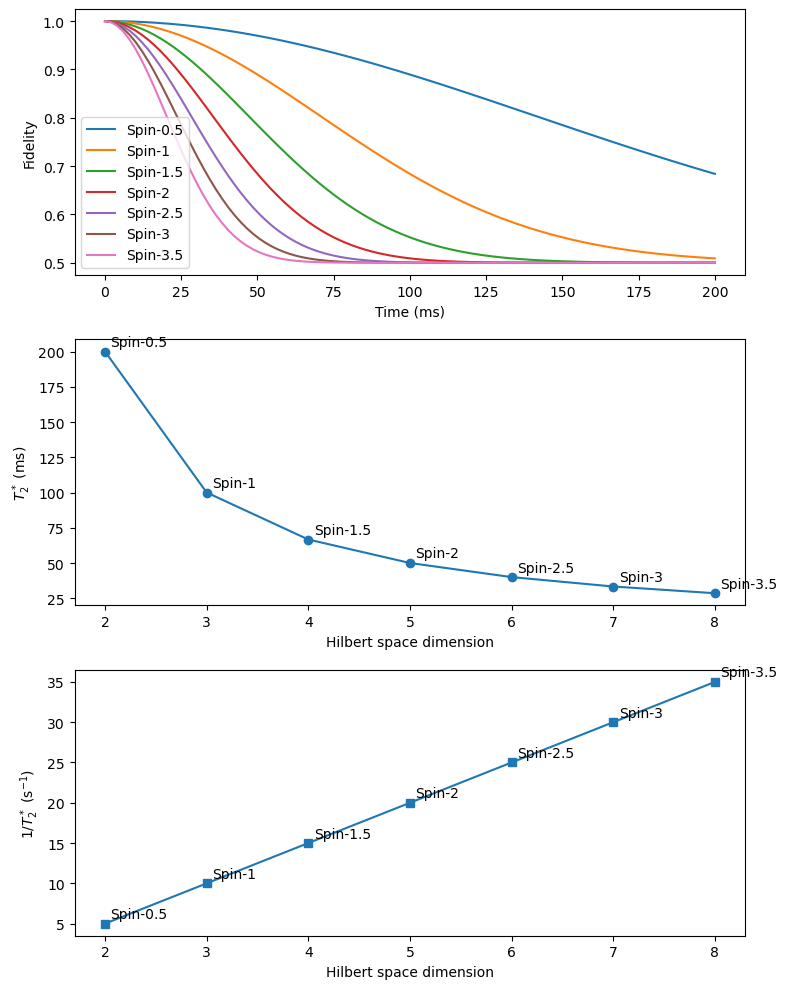

In [31]:
dims = [int(2 * I + 1) for I in spin_sizes]
labels = [f'Spin-{I}' for I in spin_sizes]

fig, axes = plt.subplots(3, 1, figsize=(8, 10), dpi=100)

for p, label in enumerate(labels):
    axes[0].plot(times * 1e3, fidelity[p], label=label)

axes[1].plot(dims, T2s * 1e3, 'o-')
for p, label in enumerate(labels):
    axes[1].annotate(label, (dims[p], T2s[p] * 1e3), textcoords='offset points', xytext=(4, 4))

axes[2].plot(dims, 1/T2s, 's-')
for p, label in enumerate(labels):
    axes[2].annotate(label, (dims[p], 1/T2s[p]), textcoords='offset points', xytext=(4, 4))

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Fidelity')
axes[0].legend()

axes[1].set_xlabel('Hilbert space dimension')
axes[1].set_ylabel(r'$T_2^*$ (ms)')

axes[2].set_xlabel('Hilbert space dimension')
axes[2].set_ylabel(r'$1/T_2^*$ (s$^{-1}$)')

plt.tight_layout()

# dephasing rate vs. exponent

In [32]:
spin_sizes = [1/2, 1, 3/2, 2, 5/2, 3, 7/2]
times = np.linspace(0, 200e-3, 100)
exponents = np.arange()

fidelity = np.zeros([len(spin_sizes), len(times)])
T2s = np.zeros(len(spin_sizes))
alphas = np.zeros(len(spin_sizes))
parities = np.zeros(len(spin_sizes))

for p, spin_size in enumerate(spin_sizes):
    nucleus = Spin(I=spin_size)
    nucleus.make_zcat_state(phi=0)
    cops = get_collapse_operators(I=spin_size, T2_star_m=T2_star_m, exponent_m=exponent_m, T2_star_e=T2_star_e, exponent_e=exponent_e)
    fidelity[p], T2s[p], alphas[p] = free_decay([nucleus.state], times, cops)
    parities[p] = nucleus.parity()

TypeError: arange() requires stop to be specified.